# Gerchberg-Saxton phase retrieval

In this tutorial, we retrieve the phase of a laser pulse from measurements of the intensity at different planes. The number of planes should be greater than or equal to two. The phase retrieval can either be done using a modal decomposition or any propagator of choice. 

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, epsilon_0

from lasy.laser import Laser
from lasy.profiles import CombinedLongitudinalTransverseProfile
from lasy.profiles.longitudinal import ContinuousWaveProfile
from lasy.profiles.transverse import (
    GaussianTransverseProfile
)

from lasy.optical_elements import Axiparabola, ParabolicMirror
from lasy.propagators import ABCD, CollinsSFFTPropagator

from lasy.utils.mode_decomposition import *
from lasy.utils.phase_retrieval import GerchbergSaxton

Next, we define the beam to be CW with a tophat profile in the transverse plane:

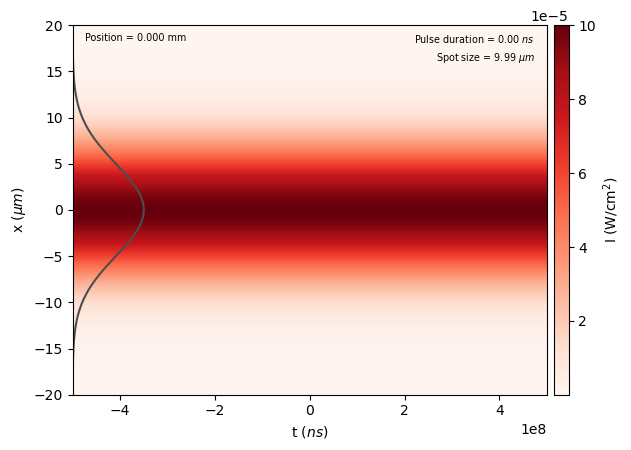

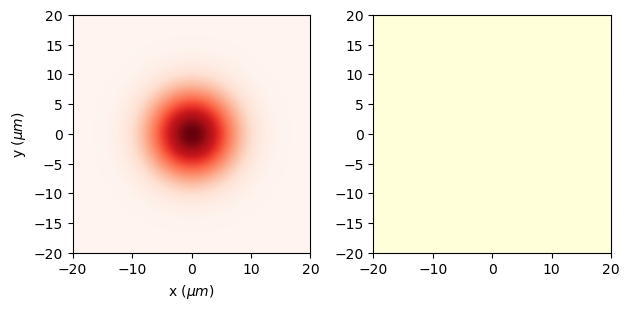

In [2]:
peak_fluence = 1.0  # J/m^2
spot_size = 10e-6
wavelength = 800e-9
omega0 = 2 * np.pi * c / wavelength
pol = (1, 0)

dimensions = "xyt"  # Use cylindrical geometry
lo = (-2.0 * spot_size, -2.0 * spot_size, None)  # Lower bounds of the simulation box
hi = (2.0 * spot_size, 2.0 * spot_size, None)  # Upper bounds of the simulation box
num_points = (256, 256, 1)  # Number of points in each dimension

long_prof = ContinuousWaveProfile(wavelength)
tran_prof = GaussianTransverseProfile(spot_size)
laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength, pol, long_prof, tran_prof, peak_fluence=peak_fluence
)

laser = Laser(dimensions, lo, hi, num_points, laser_profile)

# Plot the xt laser profile
laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

# Plot the transverse laser profile
intensity = epsilon_0 * c / 2 * np.abs(laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * laser.grid.dx[-1]
extent = (
    laser.grid.axes[0].min() * 1e6,
    laser.grid.axes[0].max() * 1e6,
    laser.grid.axes[1].min() * 1e6,
    laser.grid.axes[1].max() * 1e6,
)

fig,ax = plt.subplots(1,2)
im = ax[0].imshow(fluence,aspect='equal',extent=extent,cmap='Reds')
ax[0].set_xlabel(r'x ($\mu m$)')
ax[0].set_ylabel(r'y ($\mu m$)')
# fig.colorbar(im, ax=ax[0], label=r"Fluence (J/m$^2$)", location='left', shrink=0.4)
ax[1].imshow(np.angle(laser.grid.get_temporal_field())/(np.pi), extent=extent, cmap="YlGnBu")
plt.tight_layout()
plt.show()

In [3]:
# Modal coefficients used to construct the beam
modes = {}
modes[(0, 0)] = 1 - 0.2j
modes[(0, 1)] = -0.4 - 0.2j
modes[(1, 0)] = 0.5 + 1j
modes[(2, 2)] = -0.05 + 0.1j

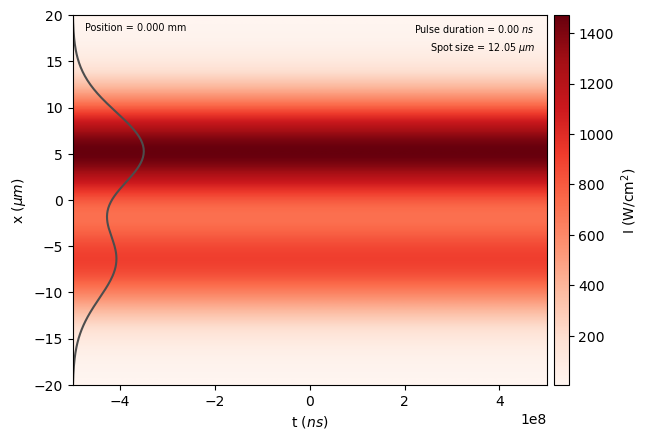

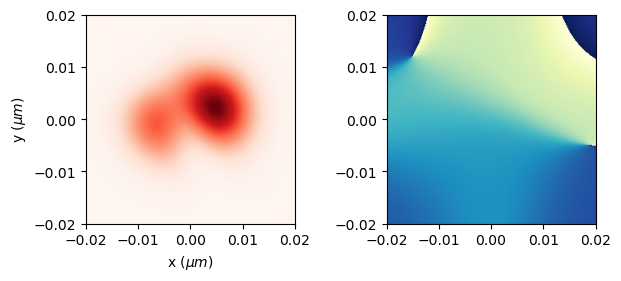

Mode coefficients for HG beam (up to third order)
0,0 :  1.00  ,  -0.20 i
0,1 :  -0.40  ,  -0.20 i
0,2 :  -0.00  ,  0.00 i
1,0 :  0.50  ,  1.00 i
1,1 :  0.00  ,  -0.00 i
1,2 :  -0.00  ,  -0.00 i
2,0 :  -0.00  ,  0.00 i
2,1 :  0.00  ,  0.00 i
2,2 :  -0.05  ,  0.10 i


In [4]:
HG_laser = deepcopy(laser)  # Make a copy of the input grid
hermite_gauss_composition(
    HG_laser, spot_size, spot_size, modes, skipAsymmetricModes=False
)

HG_laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(HG_laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * HG_laser.grid.dx[-1]
extent = (
    HG_laser.grid.axes[0].min() * 1e3,
    HG_laser.grid.axes[0].max() * 1e3,
    HG_laser.grid.axes[1].min() * 1e3,
    HG_laser.grid.axes[1].max() * 1e3,
)

fig,ax = plt.subplots(1,2)
im = ax[0].imshow(fluence,aspect='equal',extent=extent,cmap='Reds')
ax[0].set_xlabel(r'x ($\mu m$)')
ax[0].set_ylabel(r'y ($\mu m$)')
# fig.colorbar(im, ax=ax[0], label=r"Fluence (J/m$^2$)", location='left', shrink=0.4)
ax[1].imshow(np.angle(HG_laser.grid.get_temporal_field())/(np.pi), extent=extent, cmap="YlGnBu")
plt.tight_layout()
plt.show()

calculatedModes = hermite_gauss_decomposition(HG_laser, spot_size, spot_size, 3, 3)
print("Mode coefficients for HG beam (up to third order)")
for calcModeKey in calculatedModes.keys():
    print(
        "%i,%i :  %.2f  ,  %.2f i"
        % (
            calcModeKey[0],
            calcModeKey[1],
            np.real(calculatedModes[calcModeKey]),
            np.imag(calculatedModes[calcModeKey]),
        )
    )

In [5]:
zScan = 400e-6

plane2 = deepcopy(HG_laser)
plane1 = deepcopy(HG_laser)

field = [None] * 2
field[1] = plane2
plane1.propagate(-1*zScan, verbose=False)
field[0] = plane1
# HG_laser.propagate(zScan)
# field[1] = HG_laser
# HG_laser.propagate(2*zScan)
# field[3] = HG_laser
# HG_laser.propagate(zScan)
# field[4] = HG_laser

zVals = [-2*zScan,0] # [-2*zScan,-zScan,0,zScan,2*zScan]

Estimated w0(x-axis) = 10.64 microns (1/e^2 width)
Estimated w0(y-axis) = 14.21 microns (1/e^2 width)
Initial estimate of mode coefficients:
0,0 :  1.00  ,  -0.20 i
0,1 :  -0.40  ,  -0.20 i
0,2 :  -0.00  ,  0.00 i
1,0 :  0.50  ,  1.00 i
1,1 :  0.00  ,  -0.00 i
1,2 :  -0.00  ,  -0.00 i
2,0 :  -0.00  ,  0.00 i
2,1 :  0.00  ,  0.00 i
2,2 :  -0.05  ,  0.10 i


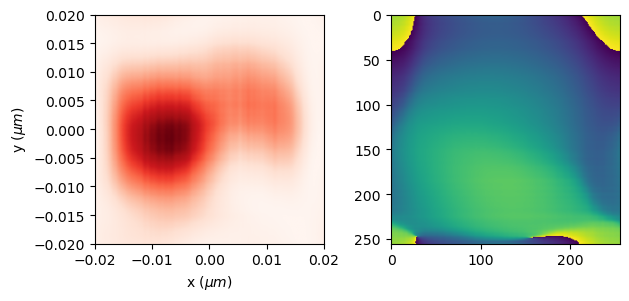

Mode coefficients for HG beam (up to third order)
0,0 :  0.88  ,  0.25 i
0,1 :  -0.06  ,  -0.37 i
0,2 :  0.16  ,  -0.21 i
1,0 :  -0.44  ,  0.83 i
1,1 :  0.00  ,  0.00 i
1,2 :  0.19  ,  0.22 i
2,0 :  0.16  ,  -0.21 i
2,1 :  -0.11  ,  -0.03 i
2,2 :  -0.05  ,  -0.10 i
Iteration 1 : Amplitude Error (summed) = 4.24e-01
Iteration 2 : Amplitude Error (summed) = 4.24e-01
Iteration 3 : Amplitude Error (summed) = 4.24e-01
Iteration 4 : Amplitude Error (summed) = 4.24e-01
Iteration 5 : Amplitude Error (summed) = 4.24e-01
Iteration 6 : Amplitude Error (summed) = 4.24e-01
Iteration 7 : Amplitude Error (summed) = 4.24e-01
Iteration 8 : Amplitude Error (summed) = 4.24e-01
Iteration 9 : Amplitude Error (summed) = 4.24e-01
Iteration 10 : Amplitude Error (summed) = 4.24e-01
Iteration 11 : Amplitude Error (summed) = 4.24e-01
Iteration 12 : Amplitude Error (summed) = 4.24e-01
Iteration 13 : Amplitude Error (summed) = 4.24e-01
Iteration 14 : Amplitude Error (summed) = 4.24e-01
Iteration 15 : Amplitude Erro

In [7]:
gs = GerchbergSaxton(field, zVals, m_max=3, n_max=3, max_iter=50, verbose=True)

gs.initialise_spotsizes((spot_size,spot_size))
gs.initialise_modes()

print("Initial estimate of mode coefficients:")
for mode in gs.modes.keys():
    print(
        "%i,%i :  %.2f  ,  %.2f i"
        % (
            mode[0],
            mode[1],
            np.real(gs.modes[mode]),
            np.imag(gs.modes[mode]),
        )
    )


intensity = epsilon_0 * c / 2 * np.abs(plane1.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * plane1.grid.dx[-1]
extent = (
    plane1.grid.axes[0].min() * 1e3,
    plane1.grid.axes[0].max() * 1e3,
    plane1.grid.axes[1].min() * 1e3,
    plane1.grid.axes[1].max() * 1e3,
)

fig,ax = plt.subplots(1,2)
im = ax[0].imshow(fluence,aspect='equal',extent=extent,cmap='Reds')
ax[0].set_xlabel(r'x ($\mu m$)')
ax[0].set_ylabel(r'y ($\mu m$)')
# fig.colorbar(im, ax=ax[0], label=r"Fluence (J/m$^2$)", location='left', shrink=0.4)
ax[1].imshow(np.angle(plane1.grid.get_temporal_field()),aspect='equal')
plt.tight_layout()
plt.show()

calculatedModes = hermite_gauss_decomposition(plane1, spot_size, spot_size, 3, 3)
print("Mode coefficients for HG beam (up to third order)")
for calcModeKey in calculatedModes.keys():
    print(
        "%i,%i :  %.2f  ,  %.2f i"
        % (
            calcModeKey[0],
            calcModeKey[1],
            np.real(calculatedModes[calcModeKey]),
            np.imag(calculatedModes[calcModeKey]),
        )
    )

phase1, phase2, errors = gs.retrieve_phase()

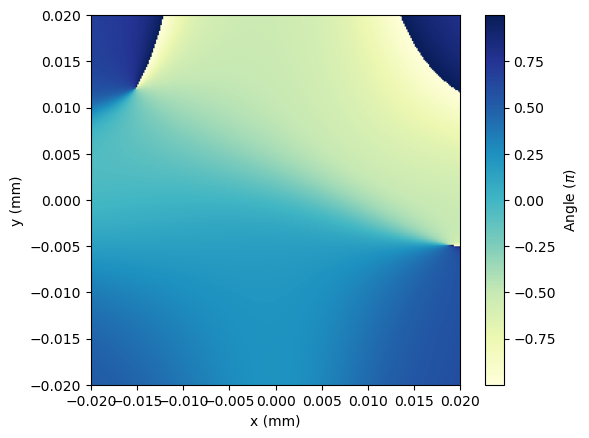

/data/dust/user/archerem/conda/conda_envs/splice2025/lib/python3.11/site-packages/cffi/_imp_emulation.py:4: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  from imp import *


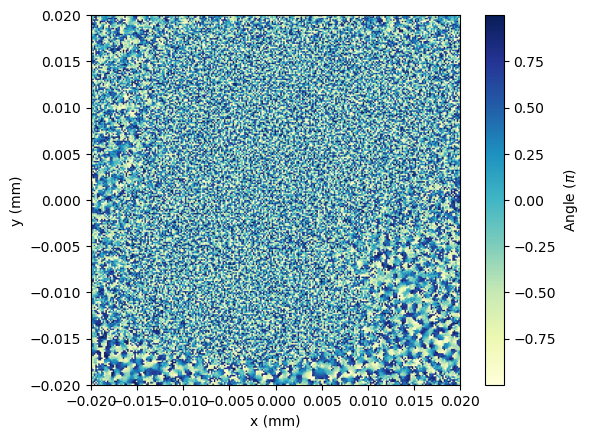

In [8]:
plt.figure()
plt.imshow(np.angle(HG_laser.grid.get_temporal_field())/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

from unwrap import unwrap
plt.figure()
plt.imshow(phase2/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

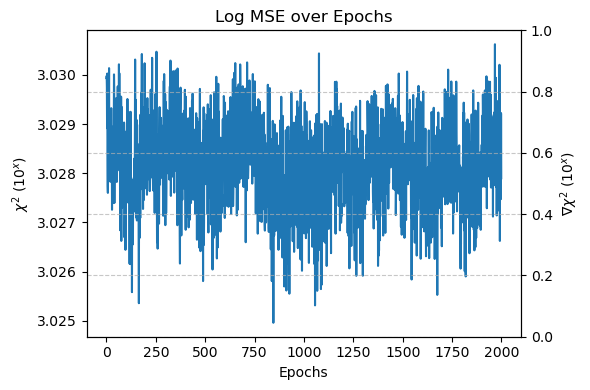

In [8]:
# Plot training and validation log MSE with 10^x format for the y-axis
def plot_log_mse(chi2):
    """
    Plots the logarithm (base 10) of training and validation MSE losses with 10^x format for the y-axis.

    Parameters:
        train_losses (list): Training MSE values over epochs.
        val_losses (list): Validation MSE values over epochs.
    """
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax2 = ax1.twinx()
    log_chi2 = np.log10(chi2+1e-8)
    
    ax1.plot(range(len(chi2)),log_chi2)
    # ax2.plot(range(len(chi2)),gradchi2, '--')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\chi^2$ ($10^x$)')
    ax2.set_ylabel(r'$\nabla \chi^2$ ($10^x$)')
    plt.title('Log MSE over Epochs')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the y-axis ticks to show as 10^x
    # y_ticks = np.arange(int(np.floor(min(log_chi2.min(), log_chi2.min()))), 
    #                     int(np.ceil(max(log_chi2.max(), log_chi2.max()))) + 1)
    # ax1.set_yticks(y_ticks)
    # ax1.set_yticklabels([r"$10^{{{}}}$".format(int(tick)) for tick in y_ticks])
    
    plt.tight_layout()
    plt.show()
plot_log_mse(errors)